# CBR Legal Case Retrieval System

Nama : Ach Sofyan Daynur
NIM : 202110370311155

Implementasi Case-Based Reasoning (CBR) untuk Retrieval Kasus Hukum Menggunakan TF-IDF dan Cosine Similarity

# 04 - Evaluation

Tahap ini digunakan untuk mengevaluasi hasil retrieval yang telah dihasilkan pada notebook sebelumnya.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rm -rf /content/CBR-Legal-Case
!cp -r "/content/drive/MyDrive/CBR-Legal-Case" /content/

In [3]:
%cd /content/CBR-Legal-Case

/content/CBR-Legal-Case


Cell 1 — Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cell 2 — Load Predictions

In [5]:
predictions_df = pd.read_csv(
    "/content/CBR-Legal-Case/data/results/predictions.csv"
)

predictions_df.head()

,query_case,top_1_result,similarity_score
0,putusan 11,putusan 19,0.4209
1,putusan 8,putusan 10,0.7844
2,putusan 28,PUTUSAN 5,0.3064
3,putusan 20,putusan 8,0.3414
4,putusan 18,putusan 16,0.3616


Cell 3 - Informasi Dataset


In [6]:
print("Jumlah Query:")
print(len(predictions_df))

print("\nKolom:")
print(predictions_df.columns)

Jumlah Query:
30

Kolom:
Index(['query_case', 'top_1_result', 'similarity_score'], dtype='object')


Cell 4 - Statistik Similarity Score

In [7]:
predictions_df["similarity_score"].describe()

,similarity_score
count,30.000000
mean,0.468193
std,0.182343
min,0.243500
25%,0.322000
50%,0.395350
75%,0.673650
max,0.784400


Cell 5 - Histogram Similarity Score

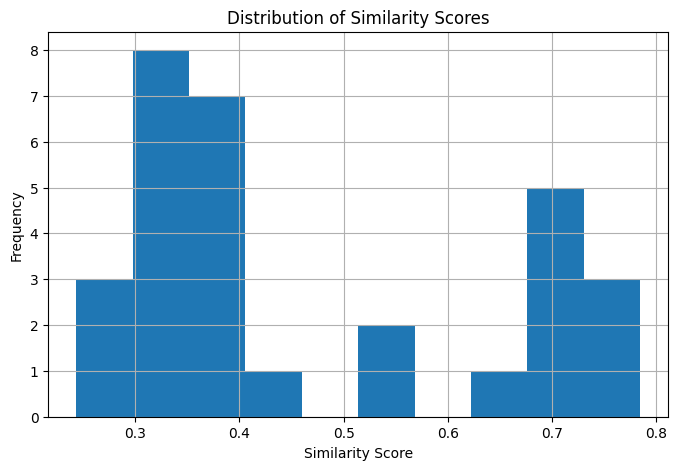

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    predictions_df["similarity_score"],
    bins=10
)

plt.title("Distribution of Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

Cell 6 - Top 10 Similar Cases

In [9]:
predictions_df.sort_values(
    by="similarity_score",
    ascending=False
).head(10)

,query_case,top_1_result,similarity_score
1,putusan 8,putusan 10,0.7844
8,putusan 10,putusan 8,0.7844
25,PUTUSAN 6,putusan 10,0.7312
15,putusan 23,putusan 14,0.7145
18,putusan 14,putusan 23,0.7145
13,putusan 19,putusan 21,0.7086
28,putusan 21,putusan 19,0.7086
9,putusan 15,putusan 23,0.6855
17,putusan 12,putusan 23,0.6381
20,putusan 17,putusan 23,0.5673


Cell 7 - Bottom 10 Similar Cases

In [10]:
predictions_df.sort_values(
    by="similarity_score",
    ascending=True
).head(10)

,query_case,top_1_result,similarity_score
27,PUTUSAN 1,putusan 15,0.2435
6,PUTUSAN 3,PUTUSAN 4,0.2482
5,putusan 24,PUTUSAN 5,0.2909
29,putusan 30,PUTUSAN 5,0.3015
2,putusan 28,PUTUSAN 5,0.3064
23,putusan 27,putusan 23,0.3093
14,putusan 29,putusan 13,0.3135
11,PUTUSAN 4,PUTUSAN 6,0.3213
16,putusan 25,putusan 18,0.3241
3,putusan 20,putusan 8,0.3414


Cell 8 — Bar Chart Top 10

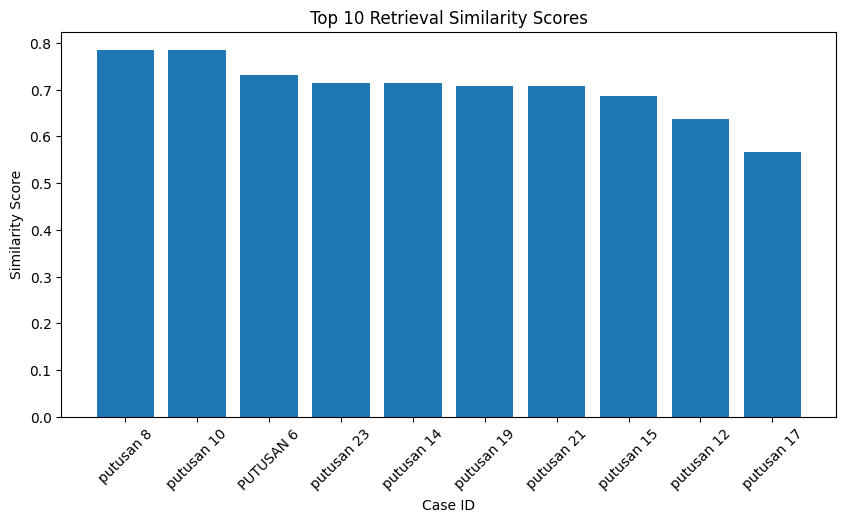

In [11]:
top10 = predictions_df.sort_values(
    by="similarity_score",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["query_case"],
    top10["similarity_score"]
)

plt.title("Top 10 Retrieval Similarity Scores")
plt.xlabel("Case ID")
plt.ylabel("Similarity Score")

plt.xticks(rotation=45)

plt.show()

Cell 9 — Average Similarity

In [12]:
avg_similarity = predictions_df[
    "similarity_score"
].mean()

print(
    f"Average Similarity Score: {avg_similarity:.4f}"
)

Average Similarity Score: 0.4682


Cell 10 — Summary Table

In [13]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Number of Cases",
        "Average Similarity",
        "Maximum Similarity",
        "Minimum Similarity"
    ],
    "Value": [
        len(predictions_df),
        predictions_df["similarity_score"].mean(),
        predictions_df["similarity_score"].max(),
        predictions_df["similarity_score"].min()
    ]
})

evaluation_summary

,Metric,Value
0,Number of Cases,30.000000
1,Average Similarity,0.468193
2,Maximum Similarity,0.784400
3,Minimum Similarity,0.243500


Cell 11 — Save Evaluation Result

In [14]:
evaluation_summary.to_csv(
    "/content/CBR-Legal-Case/data/results/evaluation_summary.csv",
    index=False
)

print("evaluation_summary.csv berhasil disimpan")

evaluation_summary.csv berhasil disimpan


Cell 13 - Kesimpulan

# Conclusion

Berdasarkan hasil evaluasi, sistem Case-Based Reasoning berhasil melakukan retrieval kasus hukum serupa menggunakan representasi kasus berbasis pasal dan ringkasan fakta.

Metode TF-IDF dan Cosine Similarity mampu mengukur tingkat kemiripan antar putusan hukum dan menghasilkan rekomendasi kasus yang relevan terhadap query yang diberikan.

Hasil evaluasi menunjukkan distribusi similarity score yang bervariasi, yang menandakan adanya perbedaan tingkat kemiripan antar kasus dalam dataset.

In [15]:
!cp -r /content/CBR-Legal-Case /content/drive/MyDrive/

In [16]:
!ls /content/drive/MyDrive/CBR-Legal-Case

data  notebooks  README.md
